## Лабораторна робота 6. **Unsupervised Learning**

Оцінювання даної роботи буде ураховувати якість Ваших висновків та візуалізацій. При наявності ЛИШЕ коду та візуалізацій без роз'яснень, робота оцінюватися НЕ БУДЕ.  

Більшість поставлених в цій лабораторній роботі задач в майбутньому буде ставитись Вами самойстійно!

Під час виконання Вам дозволено користуватися будь-якими зручними для вас бібліотеками для візуалізації.

Оформлення коментарів повинно проводитися в текстових комірках ноутбука з використанням синтаксису [LaTeX](https://en.wikibooks.org/wiki/LaTeX/Basics) для оформлення тексту та формул.

Роботи ідентифіковані як ІДЕНТИЧНІ одразу отримують 0 балів.

## Кластерування  

В цій лабораторній роботі Ви будете вирішувати задачу класифікації БЕЗ вчителя.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

import os
import warnings


warnings.filterwarnings('ignore')

**Завдання 0**

Для початку необхідно завантажити вибірку `Mall_Customers` і перейменувати атрибути `Annual Income (k$)` в `Income`,`Spending Score (1-100)` в `SpendingScore`

In [ ]:
customer_set = pd.read_csv("/content/Mall_Customers.csv")
print(customer_set)
customer_set.rename(columns={'Spending Score (1-100)': 'SpendingScore','Annual Income (k$)':'Income'},inplace=True)
print(customer_set)


     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]
     CustomerID  Gender  Age  Income  SpendingScore
0             1    Male   19      15            

**Завдання 1**

Підготовка даних до опрацювання

* подивитись які атрибути містить вибірка;
* вивести розмірність датасету;
* вивести основну статистичну інформацію по числовим змінним;  
* перевірити на наявність `NaN`.   

In [ ]:
print(customer_set.info())
print(customer_set.shape)
print(customer_set.describe())
print(customer_set.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   Income         200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
(200, 5)
       CustomerID         Age      Income  SpendingScore
count  200.000000  200.000000  200.000000     200.000000
mean   100.500000   38.850000   60.560000      50.200000
std     57.879185   13.969007   26.264721      25.823522
min      1.000000   18.000000   15.000000       1.000000
25%     50.750000   28.750000   41.500000      34.750000
50%    100.500000   36.000000   61.500000      50.000000
75%    150.250000   49.000000   78.000000      73.000000
max    200.000000   70.000000  137.000000      99.000000
CustomerID       0

## EDA Mall Customers

**Завдання 2**

Як Ви могли помітити по статистичній аналітиці вибірки вона містить змінну `CustomerID`. Ця змінна не впливає на аналіз даних тому її можна видалити.

In [ ]:
customer_set=customer_set.drop('CustomerID', axis = 1)
print(customer_set)

     Gender  Age  Income  SpendingScore
0      Male   19      15             39
1      Male   21      15             81
2    Female   20      16              6
3    Female   23      16             77
4    Female   31      17             40
..      ...  ...     ...            ...
195  Female   35     120             79
196  Female   45     126             28
197    Male   32     126             74
198    Male   32     137             18
199    Male   30     137             83

[200 rows x 4 columns]


**Завдання 3**

Побудувати діаграми розподілу по змінним `Age` , `Income` та `SpendingScore`

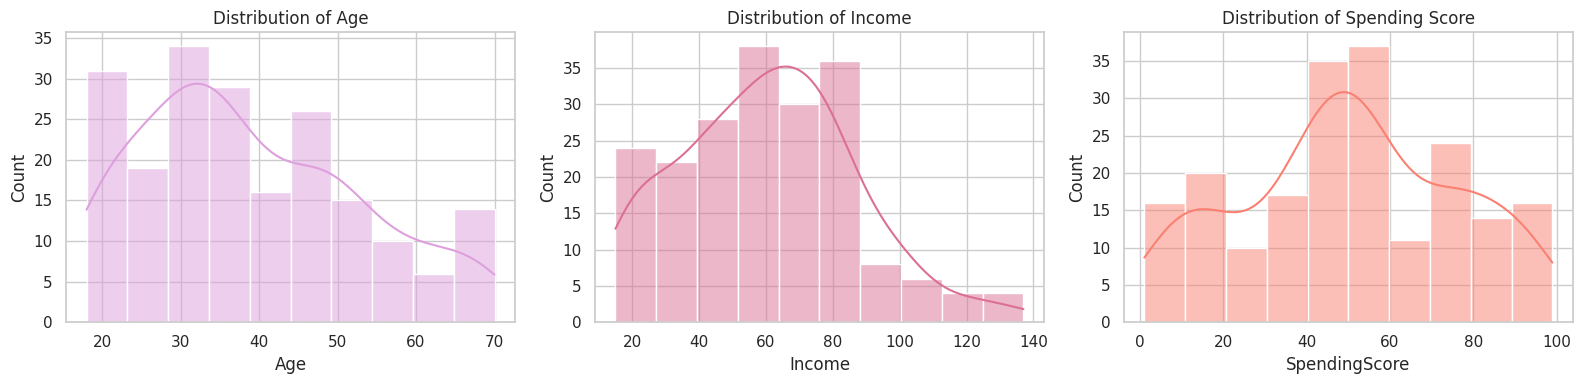

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=customer_set, x='Age', kde=True, bins=10, color='plum', ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(data=customer_set, x='Income', kde=True, bins=10, color='palevioletred', ax=axes[1])
axes[1].set_title('Distribution of Income')

sns.histplot(data=customer_set, x='SpendingScore', kde=True, bins=10, color='salmon', ax=axes[2])
axes[2].set_title('Distribution of Spending Score')

plt.tight_layout()
plt.show()

**Завдання 4**

Давайте подивимось на ці змінні `Age` , `Income` та `SpendingScore` відносно змінної `Gender`.
* Побудуємо `pairplot` по всім змінним відностно змінної `Gender`:  

* Побудуємо `pairplot` використовуючи `sns.PairGrid` із заданими `(scatterplot)`, `(kdeplot)` та `(kdeplot, lw=1)` по відповідно правому верхньому куту, діагоналі і лівому нижньому кутут відносно змінної `Gender`:  


<Figure size 640x480 with 0 Axes>

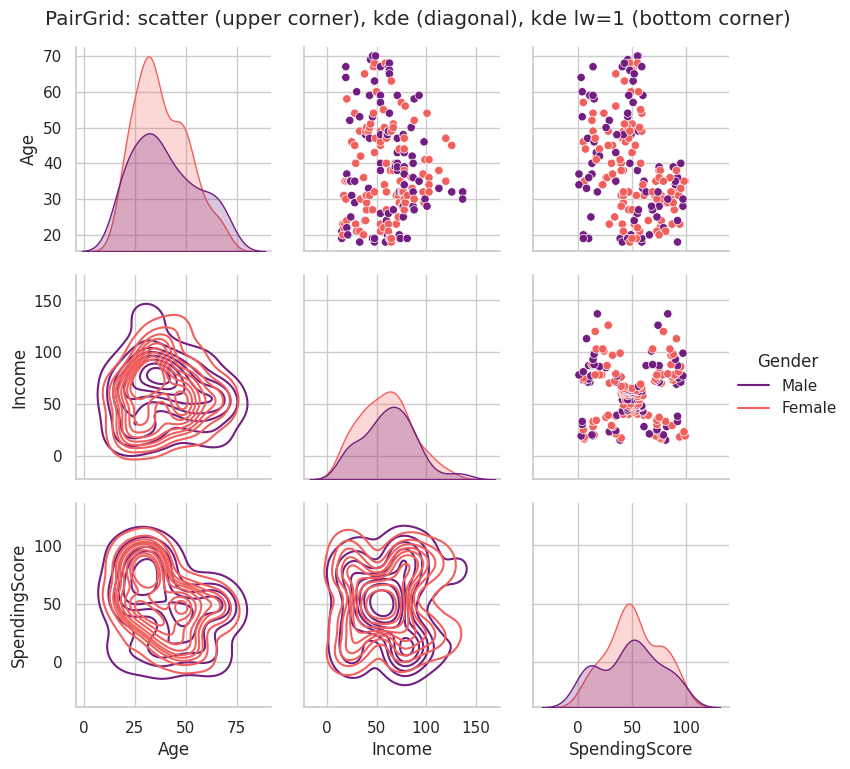

In [ ]:
plt.suptitle("Pairplot Gender", y=1.02)
plt.show()

g = sns.PairGrid(customer_set, vars=["Age", "Income", "SpendingScore"], hue="Gender", palette="magma")

g.map_upper(sns.scatterplot)

g.map_diag(sns.kdeplot, fill=True)

g.map_lower(sns.kdeplot, lw=1)

g.add_legend()
plt.suptitle("PairGrid: scatter (upper corner), kde (diagonal), kde lw=1 (bottom corner)", y=1.02)
plt.show()

**Висновки з 1-4 завдання (детальні)**

1. У нас є 200 рядків, також немає null значень. Присутні числові та категоріальний тип даних.Значення мають помітне стандартне відхилення, що свідчить про варіативність даних.
2. Ми успішно видаляєсо стовпець CustomerID
3. По першому розподілу можна побачити, що найбільше клієнтів у віці від 30 до 40 років. Також, я невеликий зсув вправо. По другому ми бачимо,що більшість клієнтів мають дохід від 60 до 80 тис доларів. Присутній хвіст спарва. Та на третьому розподілі можна спостерігати
4.

*  На першому графіку по діагоналі ми бачимо, що найбільше жінок у віці між 30-40 років, в той час як чоловіків 30-35. На другому розподіл приблизно однаковий, але у жінок трохи більше клієнтів з доходом до 50. І на третьому ми бачимо жінки демонструють більшу варіативність є як дуже економні, так і дуже активні у витратах. У чоловіків розподіл трохи більш концентрований навколо середніх значень У чоловіків спостерігаються більш середні значення.
*   На першому графіку у верхньому куті ми бачимо, що немає сильних лінійних залежностей між змінними. Також, точки обох статей змішані, однак є певна тенденція до утворення скупчень.
*  На першому графіку в нижньомк куті ми спостерігаємо, що жінки більше зосереджені в нижчих доходах і молодшому віці. На другому графіку розподіли подібні для обох статей, але у жінок трохи більше крайніх значень по SpendingScore. Та на третьому графіку є дві яскраво виражені зони — одна з низьким віком і високими витратами.






**Завдання 5**

Проаналізувати змінну `Gender`:
* вивести співвідношення по статям;
* побудувати `countplot` по `Gender`;  
* побудувати `pie`по `Gender'.  

Gender
Female    112
Male       88
Name: count, dtype: int64
Gender
Female    56.0
Male      44.0
Name: count, dtype: float64


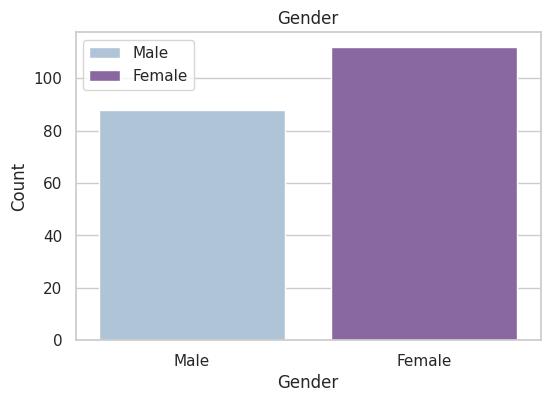

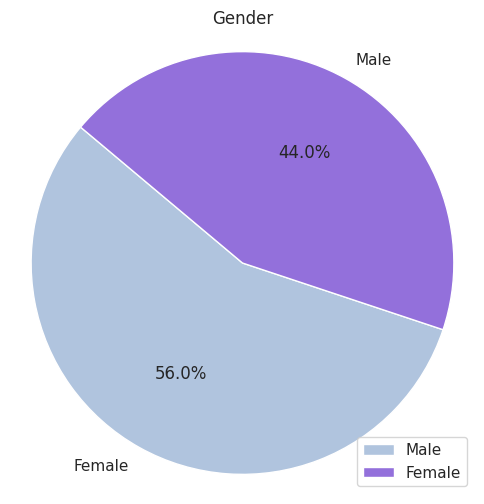

In [ ]:
gender_counts = customer_set['Gender'].value_counts()
print(gender_counts)
print((gender_counts / gender_counts.sum()) * 100)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_set, x='Gender', palette='BuPu')
plt.title('Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Male','Female'])


plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightsteelblue', 'mediumpurple'])
plt.title('Gender')
plt.axis('equal')
plt.legend(['Male','Female'])
plt.show()

**Завдання 6**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінних `Age` та `Income` відносно змінної `Gender` з різними параметрами:
*  подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.

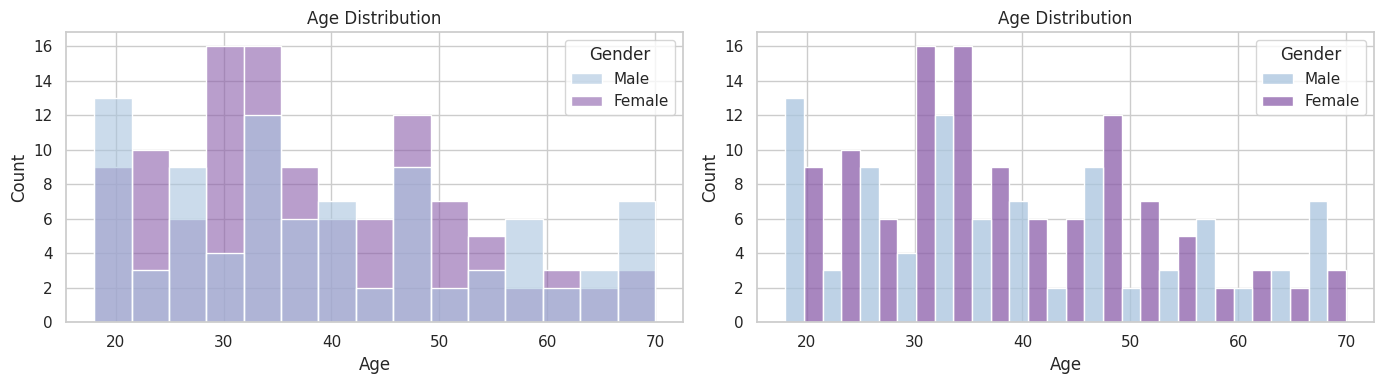

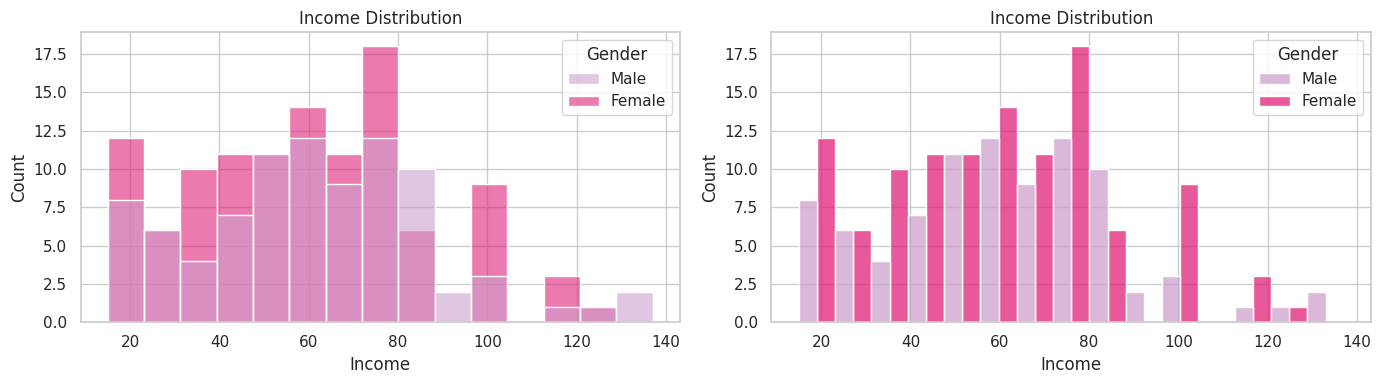

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='Age', hue='Gender', multiple='layer', bins=15, palette='BuPu', alpha=0.6)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='Age', hue='Gender', multiple='dodge', bins=15, palette='BuPu')
plt.title('Age Distribution')

plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='Income', hue='Gender', multiple='layer', bins=15, palette='PuRd', alpha=0.6)
plt.title('Income Distribution')

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='Income', hue='Gender', multiple='dodge', bins=15, palette='PuRd')
plt.title('Income Distribution')

plt.tight_layout()
plt.show()

**Завдання 7**

Побудувати гістограми [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) змінної `SpendingScore` відносно змінної `Gender` з різними параметрами:  
* подивитись на скільки змінюється візуалізація при різних значеннях параметра `multiple`, наприклад `dodge` та `layer`.



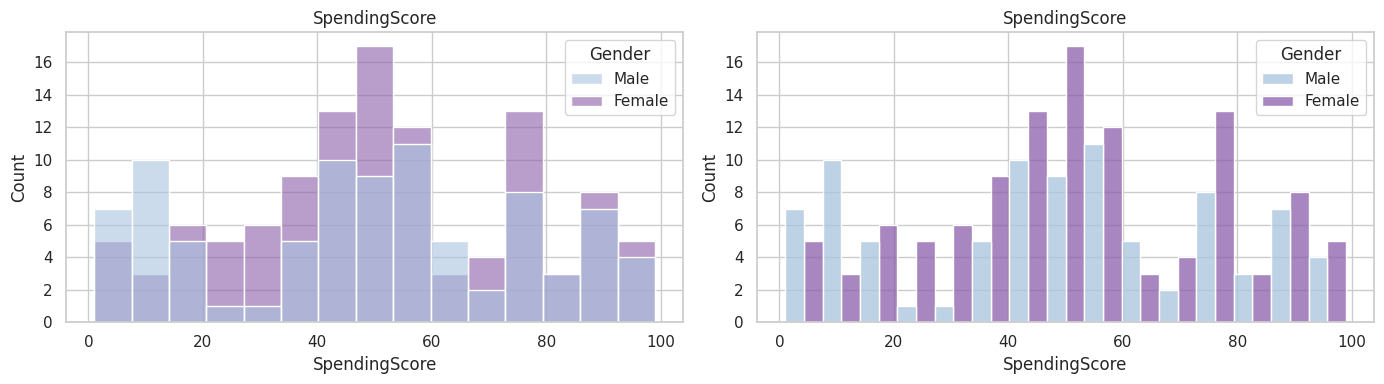

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=customer_set, x='SpendingScore', hue='Gender', multiple='layer', bins=15, palette='BuPu', alpha=0.6)
plt.title('SpendingScore')

plt.subplot(1, 2, 2)
sns.histplot(data=customer_set, x='SpendingScore', hue='Gender', multiple='dodge', bins=15, palette='BuPu')
plt.title('SpendingScore')

plt.tight_layout()
plt.show()

**Завдання 8**

Побудувати `boxplot` по змінній `SpendingScore` і подивитись як відрізняються витрати відностно змінної `Gender`.

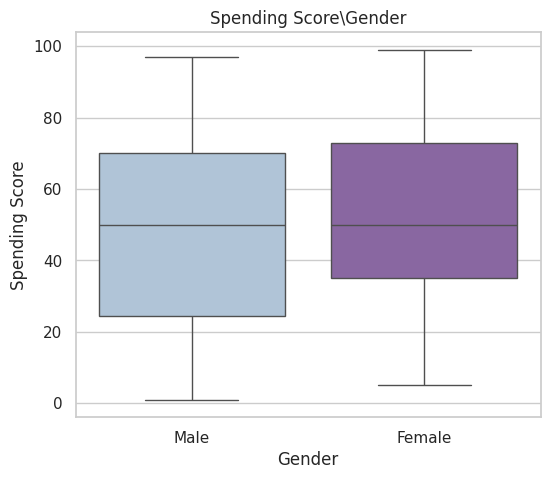

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 5))
sns.boxplot(data=customer_set, x='Gender', y='SpendingScore', palette='BuPu')
plt.title('Spending Score\Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score')
plt.show()

**Висновки з завдання 5 - 8(детальні)**

1.   Яке співвідношення груп чоловіків та жінок? 11\14
2.  Подивитись які можна виділити групи і як розподілені витрати відностно статі людини? Вікова структура показує, що більшість жінок зосереджена у молодшій віковій групі, чоловіків — у старших.Жінки мають трохи більшу кількість у середньому рівні доходів. Чоловіки частіше представлені в крайніх інтервалах доходів — як низьких, так і високих.
3. Чи є різниця між витратами у чоловіків та жінок? Жінки більш представлені серед високих оцінок витрат. Чоловіки частіше мають дуже низькі або середні оцінки витрат.
4. Жінки в середньому мають трохи вищий Spending Score, ніж чоловіки, а також їхні витрати більш варіативні. Це може свідчити про те, що жінки частіше є активнішими покупцями або клієнтами з різними стилями витрат.

## K-means Method ##

**Завдання 9**

Як Ви могли помітити, вибірка, з якою ми працюємо, не містить ключової зміної з вірними мітками. Тому перед початком кластерування необхідно визначити (підібрати) оптимальну кількість кластерів на яке буде проведено розбиття. Для цього необхідно:
1. видалити змінну `Gender`, тому що ... **Чому?**;  
2. задати мінімальну та максимальну кількість кластерів самостійно;  
3. На прикладі алгоритму [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), для ознайомлення з тим як працювати в умовах коли кількість кластерів невідома заздалегіть і немає вірних міток з позначками до якого кластеру відноситься спостереження пропонується використати метод [Elbow](https://coderoad.ru/19197715/Scikit-Learn-K-Means-Elbow-criterion) (додаткові джерела: [article_1](https://medium.com/analytics-vidhya/elbow-method-of-k-means-clustering-algorithm-a0c916adc540#:~:text=K%2Dmeans%20clustering%20is%20an,cluster%20with%20the%20nearest%20centroid.), [article_2](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/))

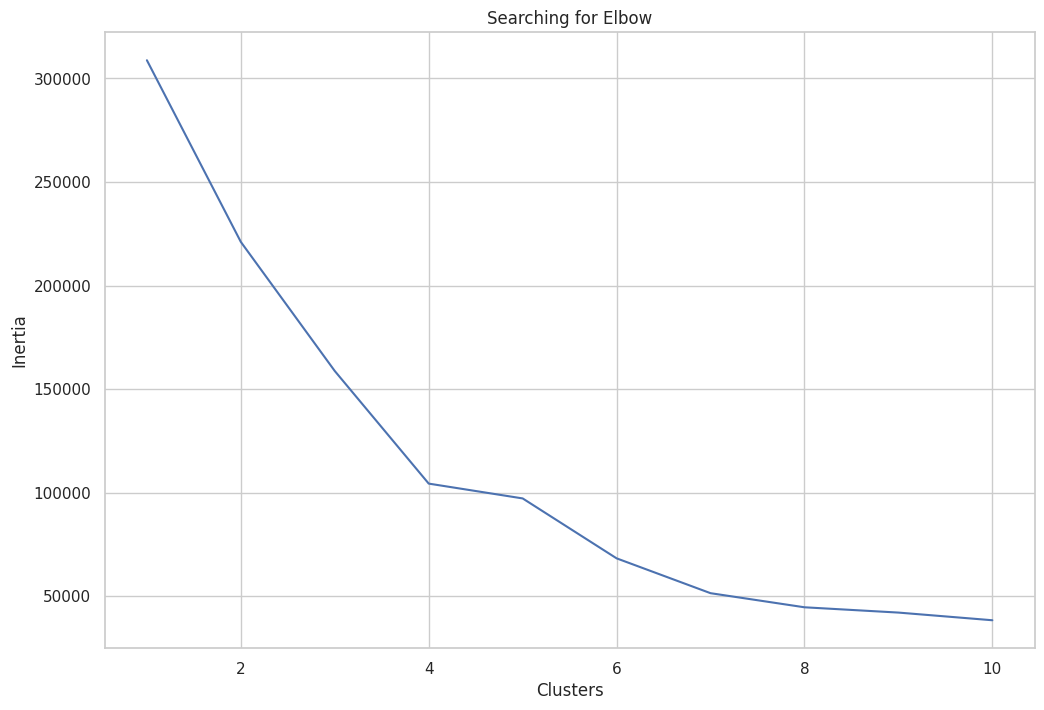

In [ ]:
X = customer_set.drop(['Gender'], axis=1)
clusters = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    clusters.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(x=list(range(1, 11)), y=clusters, ax=ax)
ax.set_title('Searching for Elbow')
ax.set_xlabel('Clusters')
ax.set_ylabel('Inertia')


plt.show()

**Висновки з завдання 9 (детальні)**

1.  Необхідно навести яка кількість кластерів на Вашу думку є оптимальною (краще розглянути для порівняння делька гіпотез про кількість кластерів)
Можна помітити при k = 4 - точка, де крива починає вирівнюватися. k = 3 — менш точне групування, але можливе, якщо потрібно спростити модель. k = 6 — якщо потрібно більш деталізоване розділення даних, хоча приріст якості вже невеликий.


**Завдання 10**

Зробити двовимірну візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи змінні `Income` та `SpendingScore`.

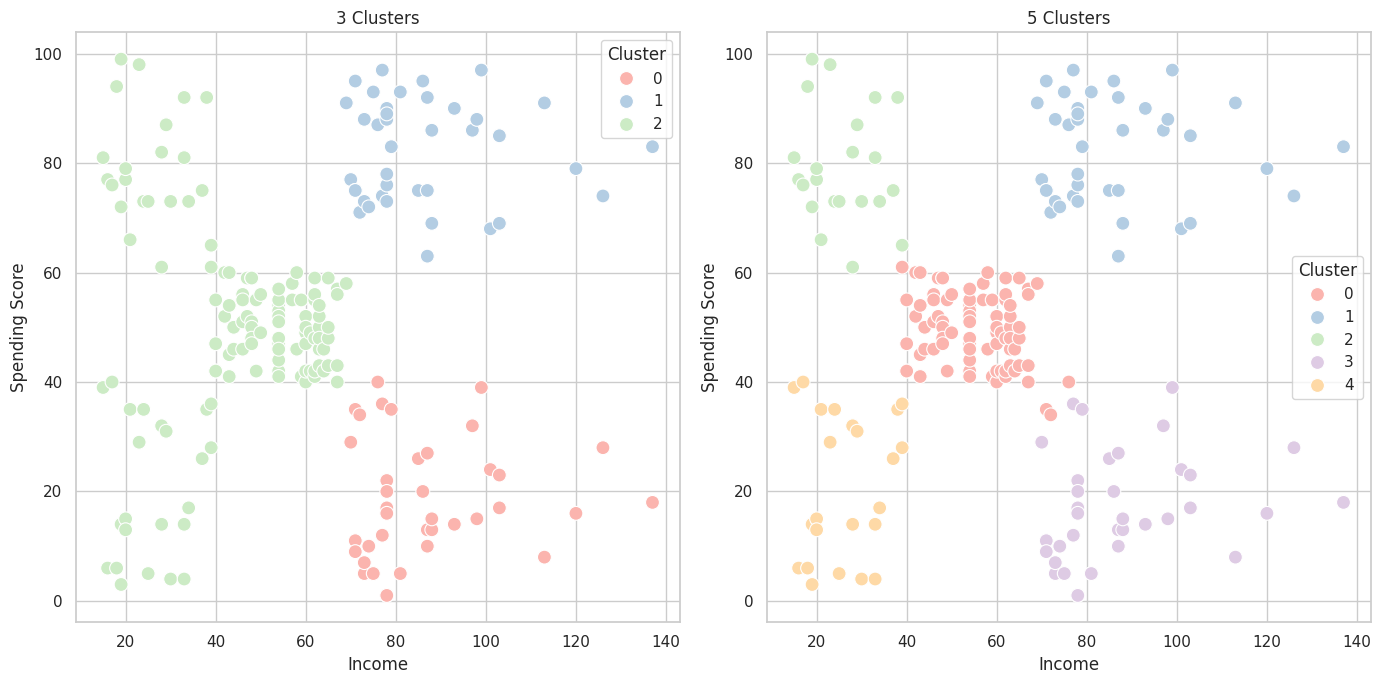

In [ ]:
X = customer_set[['Income', 'SpendingScore']]

def plot_clusters(X, n_clusters, ax, title):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    X['Cluster'] = kmeans.labels_
    sns.scatterplot(x='Income', y='SpendingScore', hue='Cluster', palette='Pastel1', data=X, ax=ax, s=100)
    ax.set_title(f'{title} Clusters')
    ax.set_xlabel('Income')
    ax.set_ylabel('Spending Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
plot_clusters(X, 3, axes[0], '3')
plot_clusters(X, 5, axes[1], '5')

plt.tight_layout()
plt.show()

**Завдання 11**

Зробити візуалізацію кластеризації методу К-середніх на вибраних Вами двох різних кількостях кластерів використовуючи [scatter_3d](https://plotly.com/python/3d-scatter-plots/).

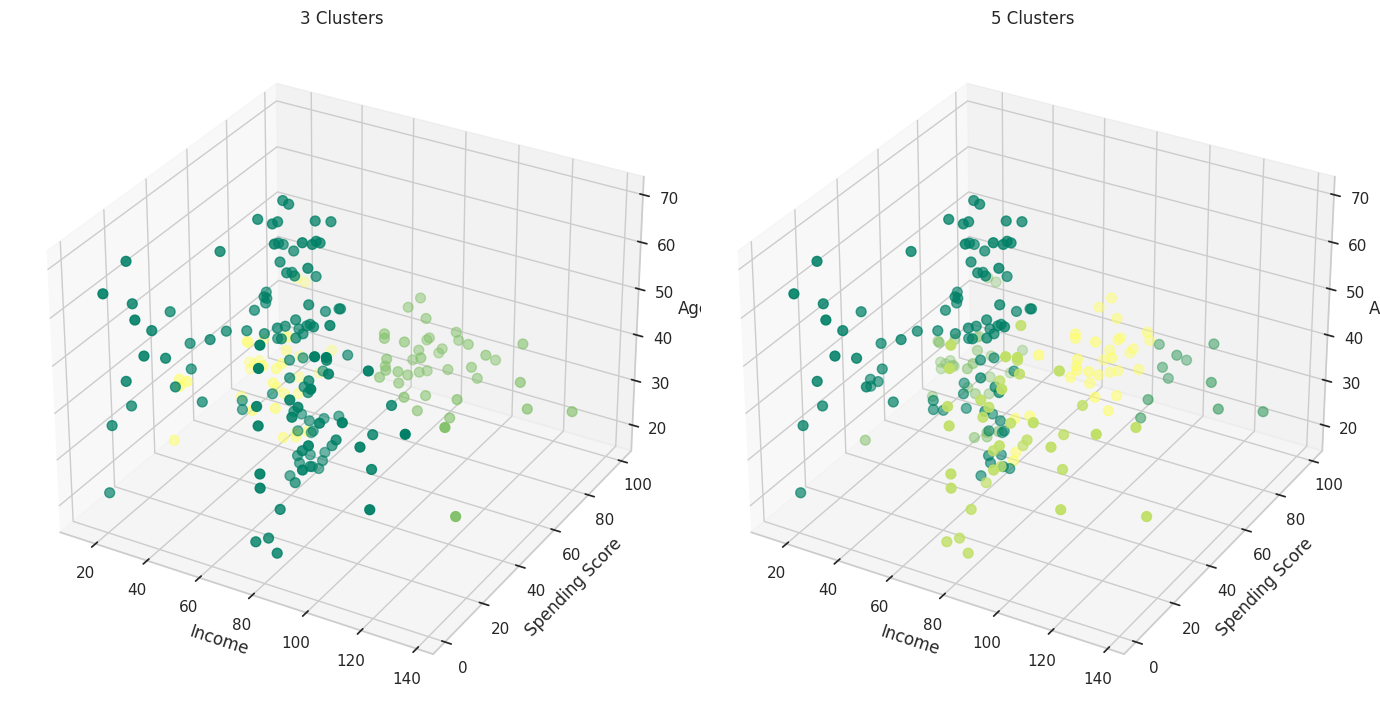

In [ ]:
X = customer_set[['Income', 'SpendingScore', 'Age']]

def plot_3d_clusters(X, n_clusters, ax, title):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    X['Cluster'] = kmeans.labels_
    ax.scatter(X['Income'], X['SpendingScore'], X['Age'], c=X['Cluster'], cmap='summer', s=50)
    ax.set_title(f'{title} Clusters')
    ax.set_xlabel('Income')
    ax.set_ylabel('Spending Score')
    ax.set_zlabel('Age')

fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(121, projection='3d')
plot_3d_clusters(X, 3, ax1, '3')
ax2 = fig.add_subplot(122, projection='3d')
plot_3d_clusters(X, 5, ax2, '5')

plt.tight_layout()
plt.show()

**Висновки з завдання 10 - 11 (детальні)**

1. Визначитась з отриманих візуалізацій яка кількість кластерів є оптимальною на Вашу думку і провести аналіз кластерів, що Ви отримали.
На мою думку, оптимальна кількість кластерів — це 5, бо саме при такій кількості чітко видно поділ на різні групи користувачів за доходом і рівнем витрат. Це дозволяє краще зрозуміти поведінку клієнтів і в подальшому можна використовувати ці дані, наприклад, для маркетингу або персоналізованих пропозицій.

## Agglomerative clustering ##

Розглянемо ще один підхід до кластеризації - [агломеративну ієрархічну кластеризацію](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

**Завдання 12**

Кластеризуйте датасет за допомогою [агломеративної ієрархічнуої кластеризації](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

Мінімально необхідні параметри, що треба налаштувати:  
* `n_clusters`: параметр, який відповідає за кільксіть кластерів на яку буде проведено розбиття вибірки;  
* `linkage`: параметр зв’язку. Цей параметр визначає, яку відстань використовувати між наборами спостережень.
* перевірте як працює цей метод з різними параметрами `linkage`  
* після кожної зміни параметрів - візуалізувати розбиття на кластери

Розрахувати матрицю відстаней для нашого набору даних:
* за допомогою методу [hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) і матриці відстаней кластеризувати дані з різними значеннями параметра `method`
* за допомогою методу [hierarchy.dendrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) візуалізувати отримані результати кластеризації у вигляді дендрограм


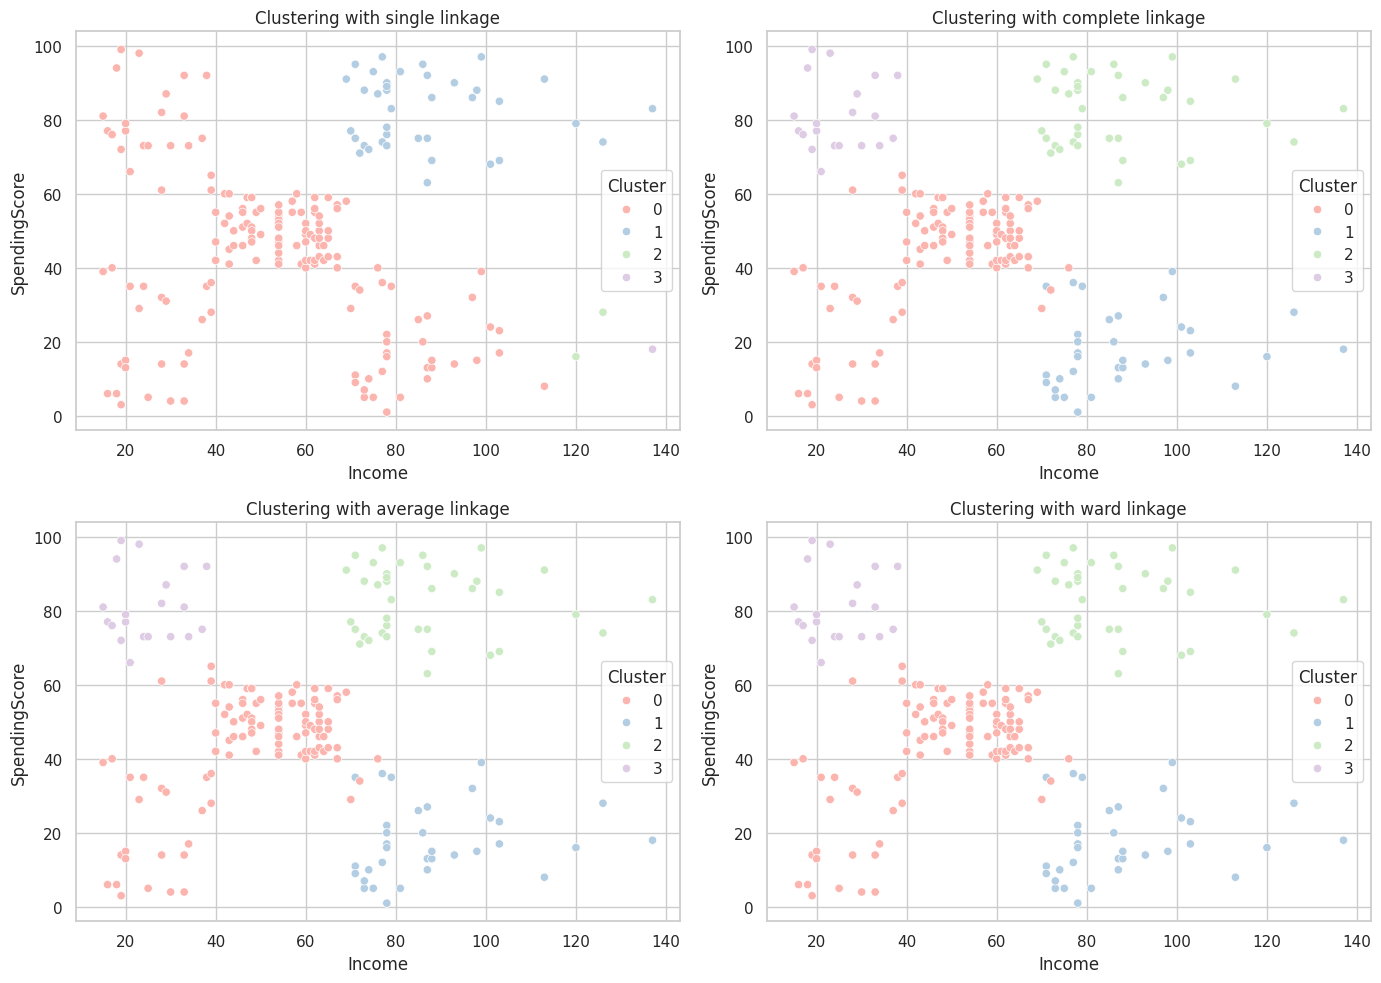

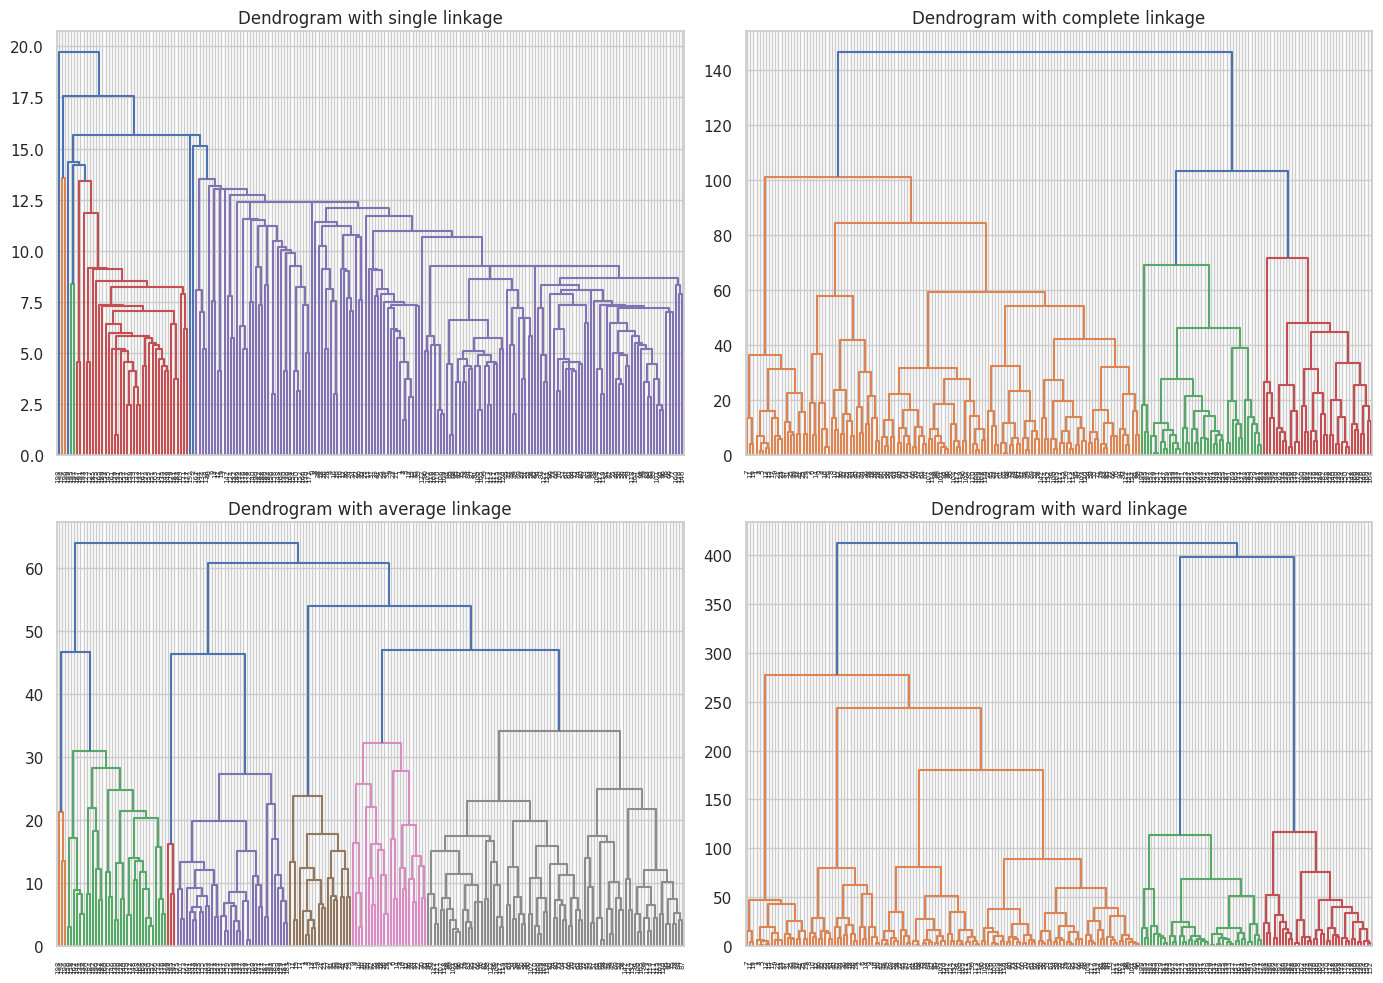

In [ ]:
n_clusters = 4

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, method in enumerate(linkage_methods):
    agglom = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    customer_set['Cluster'] = agglom.fit_predict(X)
    ax = axes[i // 2, i % 2]
    sns.scatterplot(x='Income', y='SpendingScore', hue='Cluster', data=customer_set, ax=ax, palette='Pastel1')
    ax.set_title(f'Clustering with {method} linkage')

plt.tight_layout()
plt.show()

distance_matrix = pdist(X, metric='euclidean')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, method in enumerate(linkage_methods):
    Z = hierarchy.linkage(distance_matrix, method=method)
    ax = axes[i // 2, i % 2]
    hierarchy.dendrogram(Z, ax=ax)
    ax.set_title(f'Dendrogram with {method} linkage')

plt.tight_layout()
plt.show()

**Висновки з завдання 12 (детальні)**

1. Емпірична функція розподілу побудована коректно та є монотонною. Вона показує, як змінюється накопичена частота зі збільшенням значень вибірки. Функція дозволяє оцінити ймовірність того, що випадкова величина не перевищує заданого значення. Побудова такої функції — важливий етап статистичного аналізу.
2. Полігон частот наочно відображає розподіл частот у вибірці. Його форма дозволяє візуально оцінити, де спостерігається найбільша концентрація значень. Графік допомагає визначити характер розподілу (симетричність, наявність моди), що важливо для подальших статистичних висновків.
3.  Complete linkage — створює компактні кластери, менш чутливий до шуму. Single linkage — може об’єднувати віддалені точки в один кластер (ефект ланцюга), менш надійний для реальних задач.
4. Ward linkage — формує чіткі, збалансовані кластери, підходить для більшості задач. Average linkage — компроміс між методами, стабільний результат.

**Завдання 13**

А тепер зробимо порівняльний аналіз отриманих результатів кластеризації розглянутими методами:  
* В фінальних візуалізаціях треба використовувати **однакову** (на вашу думку оптимальну) кількість кластерів!!!  

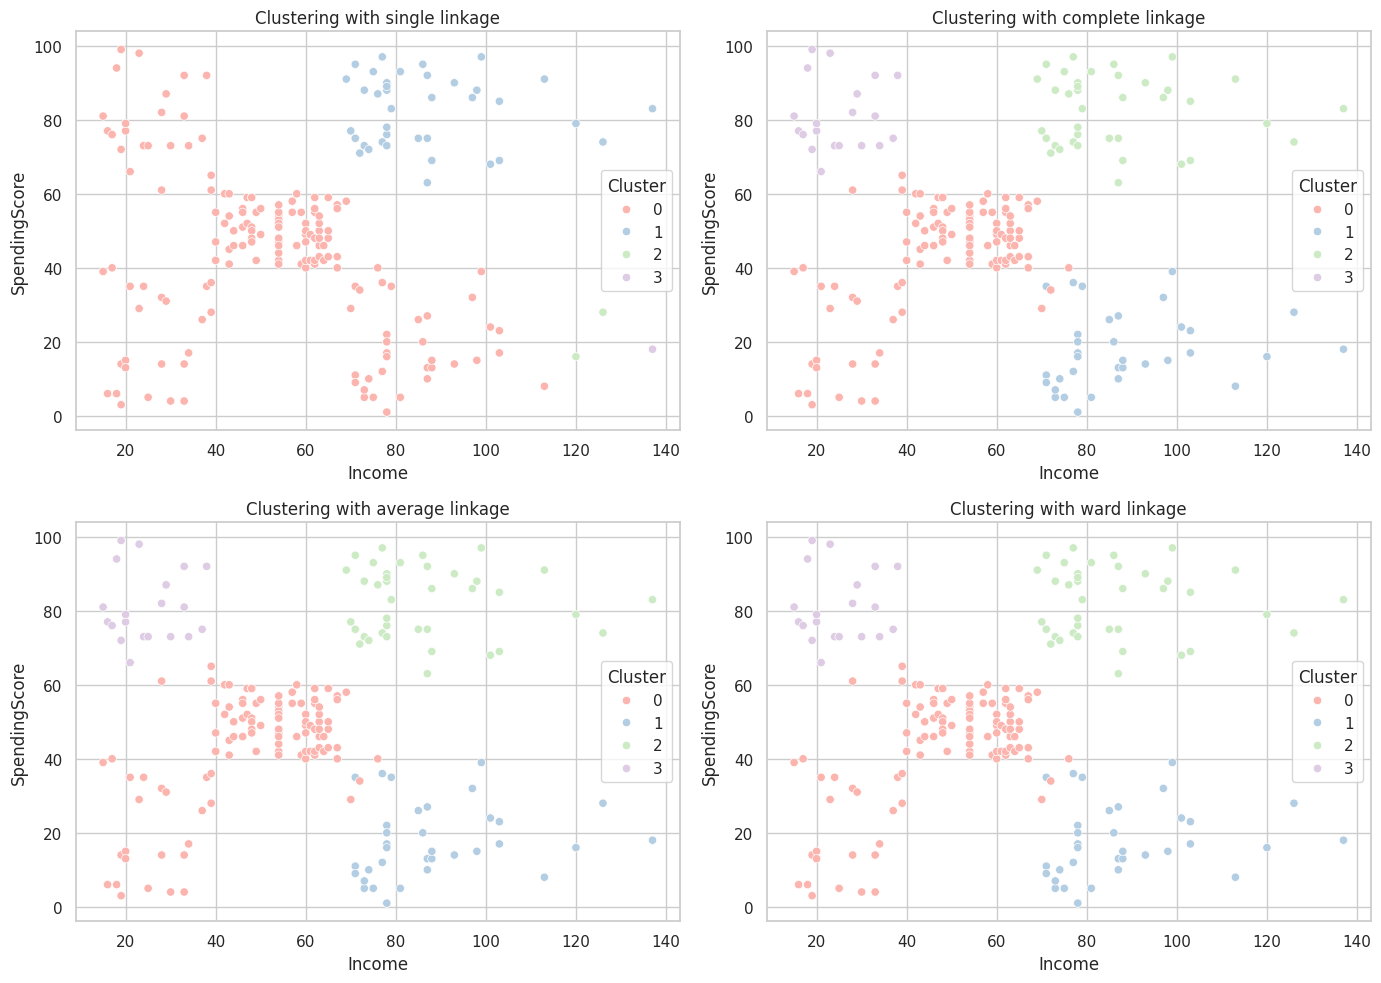

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, method in enumerate(linkage_methods):
    agglom = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    customer_set['Cluster'] = agglom.fit_predict(X)
    ax = axes[i // 2, i % 2]
    sns.scatterplot(x='Income', y='SpendingScore', hue='Cluster', data=customer_set, ax=ax, palette='Pastel1')
    ax.set_title(f'Clustering with {method} linkage')

plt.tight_layout()
plt.show()

**Висновки з завдання 13 (детальні)**

1 .Методи complete, average та особливо ward linkage демонструють більш чітке та осмислене кластеризування клієнтів за параметрами Income і SpendingScore.
Метод ward linkage виглядає оптимальним вибором для подальшого аналізу, оскільки забезпечує найкраще розділення кластерів.